# Style factor attribution

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats as scipy_stats
from pathlib import Path
import seaborn as sns
from matplotlib.ticker import MaxNLocator

## Configuration

In [2]:
# folder holding the msci index level files, monthly, gross total return, usd
data_dir = Path("../data/msci_data")

msci_index_codes = {
    "mkt": "891800",
    "value": "106063",
    "smallcap": "655061",
    "quality": "702788",
    "momentum": "703757"
}

# all 24 msci em country index codes, gross, usd, monthly, same source and settings
# as the five style indices above
country_index_codes = {
    "kor": "941000", "twn": "915800",
    "chn": "302400", "bra": "907600",
    "are": "133717", "col": "917000",
    "mex": "848400", "tur": "979200",
    "ind": "935600", "idn": "105767",
    "mys": "105768", "tha": "105769",
    "phl": "860800", "chl": "915200",
    "per": "960400", "zaf": "971000", 
    "pol": "961600", "grc": "930000",
    "hun": "934800", "qat": "133715",
    "kwt": "133713", "cze": "920000",
    "sau": "705405", "egy": "105766"
}

# number of principal components extracted from the full 24 country panel, used in
# place of the raw 24 returns so the regression stays identified
n_pca_components = 5

# location of the per month csv files written by eval_dual_path.py, one file per variant
results_dir = Path("../results/transformer")
variants = ["linear", "per_feature", "ple", "periodic", "fourier"]

# strategy and scaling labels as they appear inside per_month_{variant}.csv
col_strategy = "strategy"
col_scaling = "scaling"
col_date = "eom"
col_return = "return"

# the two long only constructions the supervisor asked to be checked
strategies_to_check = ["long_only", "country_composite_long_only"]
scaling_to_use = "unscaled"

# newey west lag length for the hac standard errors, matches the six month rebalance cadence
hac_lags = 6

factor_cols = ["mkt", "value_spread", "smallcap_spread", "quality_spread", "momentum_spread"]

plots_dir = Path("../style_attribution_outputs/plots")
tables_dir = Path("../style_attribution_outputs/tables")
plots_dir.mkdir(parents = True, exist_ok = True)
tables_dir.mkdir(parents = True, exist_ok = True)

## Loading the MSCI style index levels

In [3]:
level_series = []
for label, code in msci_index_codes.items():
    matches = sorted(data_dir.glob(f"{code}*.xlsx"))
    if not matches:
        available = sorted(p.name for p in data_dir.glob("*.xlsx"))
        raise FileNotFoundError(f"no file starting with {code} found in {data_dir}, files present are {available}")
    if len(matches) > 1:
        raise ValueError(f"more than one file starting with {code} found in {data_dir}, matches are {[m.name for m in matches]}")
    path = matches[0]

    raw = pd.read_excel(path, sheet_name = "Performance Data", header = None)
    header_row = raw.index[raw[0] == "Date"][0]
    data = raw.iloc[header_row + 1:, [0, 1]].copy()
    data.columns = ["date", label + "_level"]
    data = data.dropna(subset = ["date", label + "_level"])
    data["date"] = pd.to_datetime(data["date"])
    data[label + "_level"] = pd.to_numeric(data[label + "_level"])
    data["month"] = data["date"].dt.to_period("M")
    series = data.set_index("month")[label + "_level"]
    level_series.append(series)

levels = pd.concat(level_series, axis = 1).sort_index()
print(levels.shape)
print(levels.index.is_monotonic_increasing)
print(levels.tail())

(354, 5)
True
           mkt_level  value_level  smallcap_level  quality_level  \
month                                                              
2026-02  4403.390871   758.292206     2890.747376    2337.038333   
2026-03  3829.716868   661.373136     2569.907678    2097.165998   
2026-04  4393.809101   744.624542     2915.246334    2497.719362   
2026-05  4820.314213   820.540023     3013.801374    2699.819921   
2026-06  4754.562221   805.626656     2925.852132    2575.441903   

         momentum_level  
month                    
2026-02    19977.385612  
2026-03    16176.609720  
2026-04    21123.794979  
2026-05    26484.768379  
2026-06    26667.309880  


## Computing monthly returns and the four style spread factors

In [4]:
returns = levels.pct_change()
returns.columns = [c.replace("_level", "_ret") for c in returns.columns]

factors = pd.DataFrame(index = returns.index)
factors["mkt"] = returns["mkt_ret"]
factors["value_spread"] = returns["value_ret"] - returns["mkt_ret"]
factors["smallcap_spread"] = returns["smallcap_ret"] - returns["mkt_ret"]
factors["quality_spread"] = returns["quality_ret"] - returns["mkt_ret"]
factors["momentum_spread"] = returns["momentum_ret"] - returns["mkt_ret"]
factors = factors.dropna()

factors.to_csv(tables_dir / "msci_style_factors.csv")
print(factors.describe().round(4).to_string())

            mkt  value_spread  smallcap_spread  quality_spread  momentum_spread
count  330.0000      330.0000         330.0000        330.0000         330.0000
mean     0.0094        0.0000          -0.0001          0.0006           0.0031
std      0.0606        0.0104           0.0216          0.0162           0.0268
min     -0.2735       -0.0539          -0.0769         -0.0648          -0.1034
25%     -0.0256       -0.0067          -0.0132         -0.0081          -0.0092
50%      0.0088       -0.0003          -0.0002          0.0005           0.0021
75%      0.0476        0.0060           0.0134          0.0106           0.0174
max      0.1714        0.0359           0.0629          0.0452           0.1585


## Results, all five variants

In [5]:
all_summaries = []
cached_runs = []

for variant in variants:
    for strategy in strategies_to_check:
        path = results_dir / f"per_month_{variant}.csv"
        if not path.exists():
            print(f"skipping {variant}, {strategy}, per_month csv not found")
            continue

        df = pd.read_csv(path)
        missing_cols = [c for c in [col_strategy, col_scaling, col_date, col_return] if c not in df.columns]
        if missing_cols:
            raise KeyError(f"columns {missing_cols} not found, available columns are {list(df.columns)}")

        mask = (df[col_strategy] == strategy) & (df[col_scaling] == scaling_to_use)
        filtered = df.loc[mask, [col_date, col_return]].copy()
        if filtered.empty:
            available_strategies = df[col_strategy].unique().tolist()
            available_scalings = df[col_scaling].unique().tolist()
            raise ValueError(f"no rows for strategy {strategy}, scaling {scaling_to_use}, available strategies are {available_strategies}, available scalings are {available_scalings}")

        filtered["date"] = pd.to_datetime(filtered[col_date])
        filtered["month"] = filtered["date"].dt.to_period("M")
        portfolio_return = filtered.set_index("month")[col_return]
        portfolio_return.name = "portfolio_return"

        merged = factors.join(portfolio_return, how = "inner").dropna()

        # cumulative wealth and drawdown
        wealth = (1 + merged["portfolio_return"]).cumprod()
        drawdown = (wealth - wealth.cummax()) / wealth.cummax()
        max_drawdown = float(drawdown.min())
        print(f"max drawdown, {variant}, {strategy}, {max_drawdown:.4f}")

        # style regression, ols with newey west standard errors
        y = merged["portfolio_return"]
        x = sm.add_constant(merged[factor_cols])
        results = sm.OLS(y, x).fit(cov_type = "HAC", cov_kwds = {"maxlags": hac_lags})

        regression_labels = ["alpha (monthly)", "mkt", "value", "small cap", "quality", "momentum"]
        summary = pd.DataFrame({
            "factor": regression_labels,
            "loading": results.params.values.round(4),
            "t_stat": results.tvalues.values.round(2),
            "p_value": results.pvalues.values.round(3)
        })
        alpha_annualised = results.params["const"] * 12
        print(f"variant {variant}, strategy {strategy}, n_obs {int(results.nobs)}, r squared {results.rsquared:.3f}")
        print(summary.to_string(index = False))
        print(f"annualised alpha, simple x12, {alpha_annualised:.4f}")

        # market beta stability by year
        yearly = merged.copy()
        yearly["year"] = yearly.index.year
        yearly_rows = []
        for year, group in yearly.groupby("year"):
            # a variance with ddof = 1 is undefined on a single observation, which
            # occurs for the partial year at the end of the window, so such years are
            # reported without a beta rather than producing a divide by zero
            if len(group) < 2:
                yearly_rows.append({"year": year, "n_obs": len(group), "beta_mkt": np.nan, "corr_mkt": np.nan})
                continue
            beta = group["mkt"].cov(group["portfolio_return"]) / group["mkt"].var()
            corr = group["mkt"].corr(group["portfolio_return"])
            yearly_rows.append({"year": year, "n_obs": len(group), "beta_mkt": beta, "corr_mkt": corr})
        yearly_table = pd.DataFrame(yearly_rows)
        print(yearly_table.round(3).to_string(index = False))
        beta_std = yearly_table["beta_mkt"].std()
        sign_changes = (yearly_table["beta_mkt"].min() < 0) and (yearly_table["beta_mkt"].max() > 0)
        if sign_changes:
            print(f"note, {variant} {strategy}, yearly market beta changes sign across the window")

        # style loading directions
        direction_labels = ["market", "value", "small cap", "quality", "momentum"]
        betas = results.params[factor_cols].values
        direction_table = pd.DataFrame({
            "factor": direction_labels,
            "loading": betas.round(4),
            "direction": ["positive" if b >= 0 else "negative" for b in betas]
        })
        print(direction_table.to_string(index = False))

        # upside and downside capture
        up = merged[merged["mkt"] > 0]
        down = merged[merged["mkt"] < 0]
        up_portfolio = (1 + up["portfolio_return"]).prod() - 1
        up_market = (1 + up["mkt"]).prod() - 1
        down_portfolio = (1 + down["portfolio_return"]).prod() - 1
        down_market = (1 + down["mkt"]).prod() - 1
        upside_capture = up_portfolio / up_market * 100
        downside_capture = down_portfolio / down_market * 100
        print(f"upside capture {upside_capture:.1f} percent over {len(up)} months, downside capture {downside_capture:.1f} percent over {len(down)} months")

        all_summaries.append({
            "variant": variant,
            "strategy": strategy,
            "n_obs": int(results.nobs),
            "r_squared": results.rsquared,
            "alpha_monthly": results.params["const"],
            "alpha_annualised": alpha_annualised,
            "beta_mkt": results.params["mkt"],
            "beta_value": results.params["value_spread"],
            "beta_smallcap": results.params["smallcap_spread"],
            "beta_quality": results.params["quality_spread"],
            "beta_momentum": results.params["momentum_spread"],
            "upside_capture": upside_capture,
            "downside_capture": downside_capture,
            "max_drawdown": max_drawdown,
            "beta_mkt_year_std": beta_std,
            "beta_mkt_sign_changes": sign_changes
        })

        cached_runs.append({
            "variant": variant,
            "strategy": strategy,
            "results": results,
            "merged": merged,
            "wealth": wealth,
            "drawdown": drawdown,
            "upside_capture": upside_capture,
            "downside_capture": downside_capture
        })

summary_table = pd.DataFrame(all_summaries)
summary_table.to_csv(tables_dir / "style_attribution_summary.csv", index = False)
print(summary_table.round(4).to_string(index = False))

max drawdown, linear, long_only, -0.0929
variant linear, strategy long_only, n_obs 60, r squared 0.422
         factor  loading  t_stat  p_value
alpha (monthly)   0.0211    4.81    0.000
            mkt   0.6653    4.85    0.000
          value   1.8619    2.47    0.014
      small cap   0.8667    5.50    0.000
        quality  -0.3813   -1.48    0.140
       momentum  -0.1381   -0.82    0.410
annualised alpha, simple x12, 0.2531
 year  n_obs  beta_mkt  corr_mkt
 2021     11    -0.150    -0.083
 2022     12     0.587     0.709
 2023     12     0.452     0.813
 2024     12    -0.047    -0.060
 2025     12    -0.053    -0.065
 2026      1       NaN       NaN
note, linear long_only, yearly market beta changes sign across the window
   factor  loading direction
   market   0.6653  positive
    value   1.8619  positive
small cap   0.8667  positive
  quality  -0.3813  negative
 momentum  -0.1381  negative
upside capture 153.6 percent over 36 months, downside capture -83.0 percent over 24 mon

## Cross variant sign agreement

In [6]:
beta_cols = ["beta_mkt", "beta_value", "beta_smallcap", "beta_quality", "beta_momentum"]
agreement_rows = []
for strategy, group in summary_table.groupby("strategy"):
    for col in beta_cols:
        n_positive = int((group[col] > 0).sum())
        n_negative = int((group[col] < 0).sum())
        agreement_rows.append({
            "strategy": strategy,
            "factor": col.replace("beta_", ""),
            "n_variants": len(group),
            "n_positive": n_positive,
            "n_negative": n_negative,
            "sign_agreement": max(n_positive, n_negative)
        })

agreement_table = pd.DataFrame(agreement_rows)
agreement_table.to_csv(tables_dir / "style_attribution_sign_agreement.csv", index = False)
print(agreement_table.to_string(index = False))

                   strategy   factor  n_variants  n_positive  n_negative  sign_agreement
country_composite_long_only      mkt           5           5           0               5
country_composite_long_only    value           5           5           0               5
country_composite_long_only smallcap           5           5           0               5
country_composite_long_only  quality           5           5           0               5
country_composite_long_only momentum           5           0           5               5
                  long_only      mkt           5           5           0               5
                  long_only    value           5           5           0               5
                  long_only smallcap           5           5           0               5
                  long_only  quality           5           1           4               4
                  long_only momentum           5           1           4               4


## Testing country concentration as an additional driver

In [7]:
country_level_series = []
for label, code in country_index_codes.items():
    matches = sorted(data_dir.glob(f"{code}*.xlsx"))
    if not matches:
        available = sorted(p.name for p in data_dir.glob("*.xlsx"))
        raise FileNotFoundError(f"no file starting with {code} found in {data_dir}, files present are {available}")
    if len(matches) > 1:
        raise ValueError(f"more than one file starting with {code} found in {data_dir}, matches are {[m.name for m in matches]}")
    path = matches[0]

    raw = pd.read_excel(path, sheet_name = "Performance Data", header = None)
    header_row = raw.index[raw[0] == "Date"][0]
    data = raw.iloc[header_row + 1:, [0, 1]].copy()
    data.columns = ["date", label + "_level"]
    data = data.dropna(subset = ["date", label + "_level"])
    data["date"] = pd.to_datetime(data["date"])
    data[label + "_level"] = pd.to_numeric(data[label + "_level"])
    data["month"] = data["date"].dt.to_period("M")
    series = data.set_index("month")[label + "_level"]
    country_level_series.append(series)

country_levels = pd.concat(country_level_series, axis = 1).sort_index()
country_returns = country_levels.pct_change()
country_returns.columns = [c.replace("_level", "_ret") for c in country_returns.columns]
country_returns.to_csv(tables_dir / "msci_country_returns_24.csv")
print(country_returns.shape)
print(country_returns.describe().round(4).to_string())

(332, 24)
        kor_ret   twn_ret   chn_ret   bra_ret   are_ret   col_ret   mex_ret   tur_ret   ind_ret   idn_ret   mys_ret   tha_ret   phl_ret   chl_ret   per_ret   zaf_ret   pol_ret   grc_ret   hun_ret   qat_ret   kwt_ret   cze_ret   sau_ret   egy_ret
count  331.0000  331.0000  331.0000  331.0000  254.0000  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000  331.0000  254.0000  254.0000  331.0000  143.0000  331.0000
mean     0.0141    0.0114    0.0081    0.0129    0.0057    0.0161    0.0107    0.0131    0.0118    0.0109    0.0081    0.0106    0.0058    0.0084    0.0162    0.0106    0.0098    0.0009    0.0124    0.0054    0.0058    0.0140    0.0048    0.0120
std      0.0920    0.0736    0.0812    0.1019    0.0852    0.0934    0.0693    0.1282    0.0769    0.0932    0.0563    0.0828    0.0682    0.0675    0.0814    0.0737    0.0914    0.1008    0.0926    0.0679    0.0562    0.0757    0.0562    0.0952
min   

### PCA test, all 24 countries

In [8]:
country_returns_common = country_returns.dropna()
standardised = (country_returns_common - country_returns_common.mean()) / country_returns_common.std()

u, s, vt = np.linalg.svd(standardised.values, full_matrices = False)
explained_variance_ratio = (s ** 2) / (s ** 2).sum()

pca_scores = pd.DataFrame(
    u[:, :n_pca_components] * s[:n_pca_components],
    index = country_returns_common.index,
    columns = [f"pc{i + 1}" for i in range(n_pca_components)]
)
pca_cols = list(pca_scores.columns)

print("explained variance ratio, first", n_pca_components, "components")
print(pd.Series(explained_variance_ratio[:n_pca_components], index = pca_cols).round(4).to_string())
print("cumulative:", round(explained_variance_ratio[:n_pca_components].sum(), 4))

explained variance ratio, first 5 components
pc1    0.4612
pc2    0.0663
pc3    0.0530
pc4    0.0493
pc5    0.0454
cumulative: 0.6752


In [9]:
country_labels_24: list[str] = [label.upper() for label in country_index_codes.keys()]
loadings = pd.DataFrame(vt[:n_pca_components].T.tolist(), index = country_labels_24, columns = pca_cols)

all_loadings_rows = []
for pc in pca_cols:
    ranked = loadings[pc].abs().sort_values(ascending = False).index
    for rank, country in enumerate(ranked, start = 1):
        cell_value = loadings.loc[[country], pc].to_numpy()
        all_loadings_rows.append({
            "component": pc,
            "rank": rank,
            "country": country,
            "loading": round(float(cell_value[0]), 3)
        })

all_loadings_table = pd.DataFrame(all_loadings_rows)
all_loadings_table.to_csv(tables_dir / "style_attribution_pca_country_loadings.csv", index = False)
print(all_loadings_table.to_string(index = False))

component  rank country  loading
      pc1     1     ZAF    0.252
      pc1     2     POL    0.237
      pc1     3     MEX    0.234
      pc1     4     PER    0.232
      pc1     5     MYS    0.231
      pc1     6     BRA    0.229
      pc1     7     CHL    0.221
      pc1     8     HUN    0.220
      pc1     9     COL    0.220
      pc1    10     CZE    0.220
      pc1    11     THA    0.214
      pc1    12     PHL    0.209
      pc1    13     GRC    0.203
      pc1    14     IND    0.203
      pc1    15     KOR    0.202
      pc1    16     TWN    0.199
      pc1    17     ARE    0.194
      pc1    18     IDN    0.182
      pc1    19     QAT    0.174
      pc1    20     KWT    0.173
      pc1    21     TUR    0.157
      pc1    22     CHN    0.152
      pc1    23     SAU    0.150
      pc1    24     EGY    0.134
      pc2     1     KWT    0.429
      pc2     2     SAU    0.409
      pc2     3     ARE    0.369
      pc2     4     TWN   -0.303
      pc2     5     QAT    0.292
      pc2 

In [10]:
pca_factors = factors.join(pca_scores, how = "inner").dropna()

pca_country_summaries = []

for variant in variants:
    for strategy in strategies_to_check:
        path = results_dir / f"per_month_{variant}.csv"
        if not path.exists():
            print(f"skipping {variant}, {strategy}, per_month csv not found")
            continue

        df = pd.read_csv(path)
        missing_cols = [c for c in [col_strategy, col_scaling, col_date, col_return] if c not in df.columns]
        if missing_cols:
            raise KeyError(f"columns {missing_cols} not found, available columns are {list(df.columns)}")

        mask = (df[col_strategy] == strategy) & (df[col_scaling] == scaling_to_use)
        filtered = df.loc[mask, [col_date, col_return]].copy()
        if filtered.empty:
            available_strategies = df[col_strategy].unique().tolist()
            available_scalings = df[col_scaling].unique().tolist()
            raise ValueError(f"no rows for strategy {strategy}, scaling {scaling_to_use}, available strategies are {available_strategies}, available scalings are {available_scalings}")

        filtered["date"] = pd.to_datetime(filtered[col_date])
        filtered["month"] = filtered["date"].dt.to_period("M")
        portfolio_return = filtered.set_index("month")[col_return]
        # target_1m in eval_dual_path.py is aliased from ret_exc_lead1m, the jkp next
        # month excess return, so the return recorded against a given eom is the return
        # earned in the following month. we advance the index by one month so it aligns
        # with the calendar month the return was actually earned in
        portfolio_return.index = portfolio_return.index + 1
        portfolio_return.name = "portfolio_return"

        merged = pca_factors.join(portfolio_return, how = "inner").dropna()

        y = merged["portfolio_return"]
        x_restricted = sm.add_constant(merged[factor_cols])
        x_full = sm.add_constant(merged[factor_cols + pca_cols])

        restricted_plain = sm.OLS(y, x_restricted).fit()
        full_plain = sm.OLS(y, x_full).fit()
        full_hac = sm.OLS(y, x_full).fit(cov_type = "HAC", cov_kwds = {"maxlags": hac_lags})

        q = len(pca_cols)
        n = int(full_plain.nobs)
        k = x_full.shape[1]
        f_stat = ((restricted_plain.ssr - full_plain.ssr) / q) / (full_plain.ssr / (n - k))
        p_value = 1 - scipy_stats.f.cdf(f_stat, q, n - k)
        baseline_r2 = restricted_plain.rsquared
        extended_r2 = full_plain.rsquared

        print(f"variant {variant}, strategy {strategy}, 24 country pca, baseline r squared {baseline_r2:.3f}, extended r squared {extended_r2:.3f}, incremental r squared {extended_r2 - baseline_r2:.3f}")
        print(f"joint test on {q} extra regressors, f statistic {f_stat:.2f}, p value {p_value:.3f}")
        pc_table = pd.DataFrame({
            "regressor": pca_cols,
            "loading": full_hac.params[pca_cols].values.round(4),
            "t_stat": full_hac.tvalues[pca_cols].values.round(2),
            "p_value": full_hac.pvalues[pca_cols].values.round(3)
        })
        print(pc_table.to_string(index = False))

        row = {
            "variant": variant,
            "strategy": strategy,
            "baseline_r_squared": baseline_r2,
            "extended_r_squared": extended_r2,
            "incremental_r_squared": extended_r2 - baseline_r2,
            "f_stat": f_stat,
            "p_value": p_value
        }
        for _, pc_row in pc_table.iterrows():
            row[f"beta_{pc_row['regressor'].lower()}"] = pc_row["loading"]
        pca_country_summaries.append(row)

pca_country_summary_table = pd.DataFrame(pca_country_summaries)
pca_country_summary_table.to_csv(tables_dir / "style_attribution_pca_country_test.csv", index = False)
print(pca_country_summary_table.round(4).to_string(index = False))

variant linear, strategy long_only, 24 country pca, baseline r squared 0.068, extended r squared 0.185, incremental r squared 0.116
joint test on 5 extra regressors, f statistic 1.40, p value 0.242
regressor  loading  t_stat  p_value
      pc1  -0.0071   -1.28    0.200
      pc2  -0.0002   -0.03    0.979
      pc3   0.0081    1.37    0.171
      pc4   0.0008    0.13    0.898
      pc5   0.0040    0.76    0.449
variant linear, strategy country_composite_long_only, 24 country pca, baseline r squared 0.110, extended r squared 0.165, incremental r squared 0.055
joint test on 5 extra regressors, f statistic 0.65, p value 0.662
regressor  loading  t_stat  p_value
      pc1  -0.0040   -0.81    0.420
      pc2   0.0029    0.49    0.627
      pc3   0.0000    0.01    0.991
      pc4  -0.0021   -0.64    0.523
      pc5   0.0041    0.90    0.366
variant per_feature, strategy long_only, 24 country pca, baseline r squared 0.019, extended r squared 0.112, incremental r squared 0.093
joint test on 5 e

## Charts

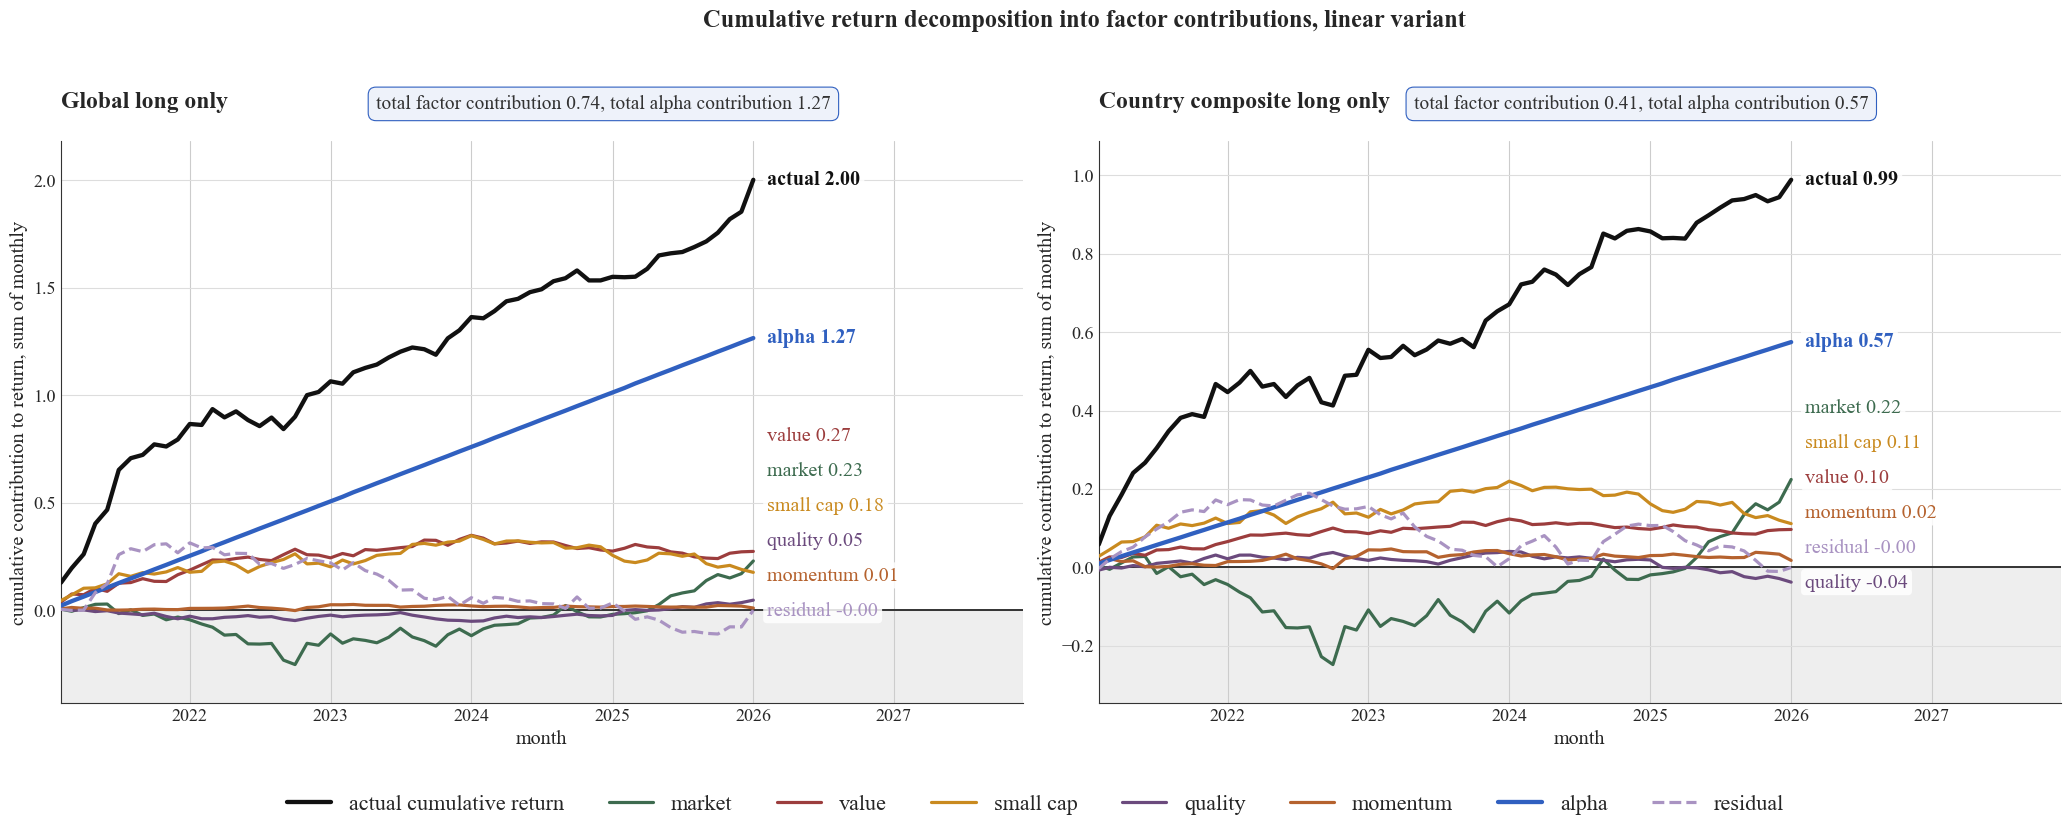

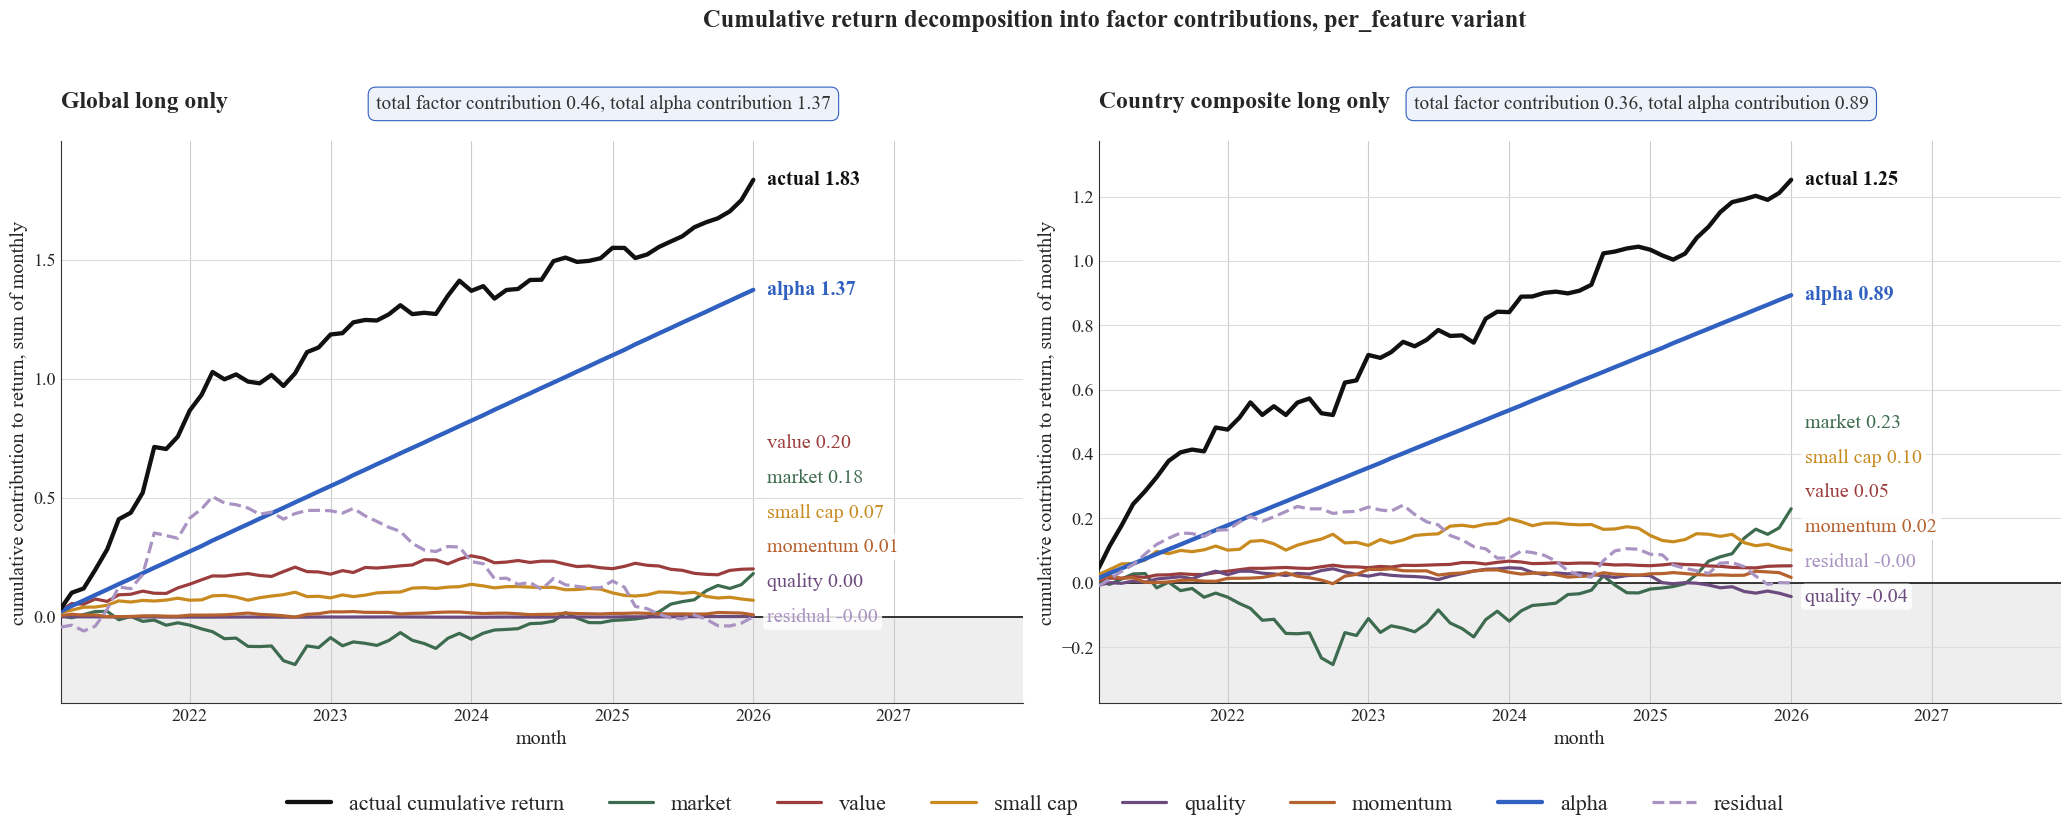

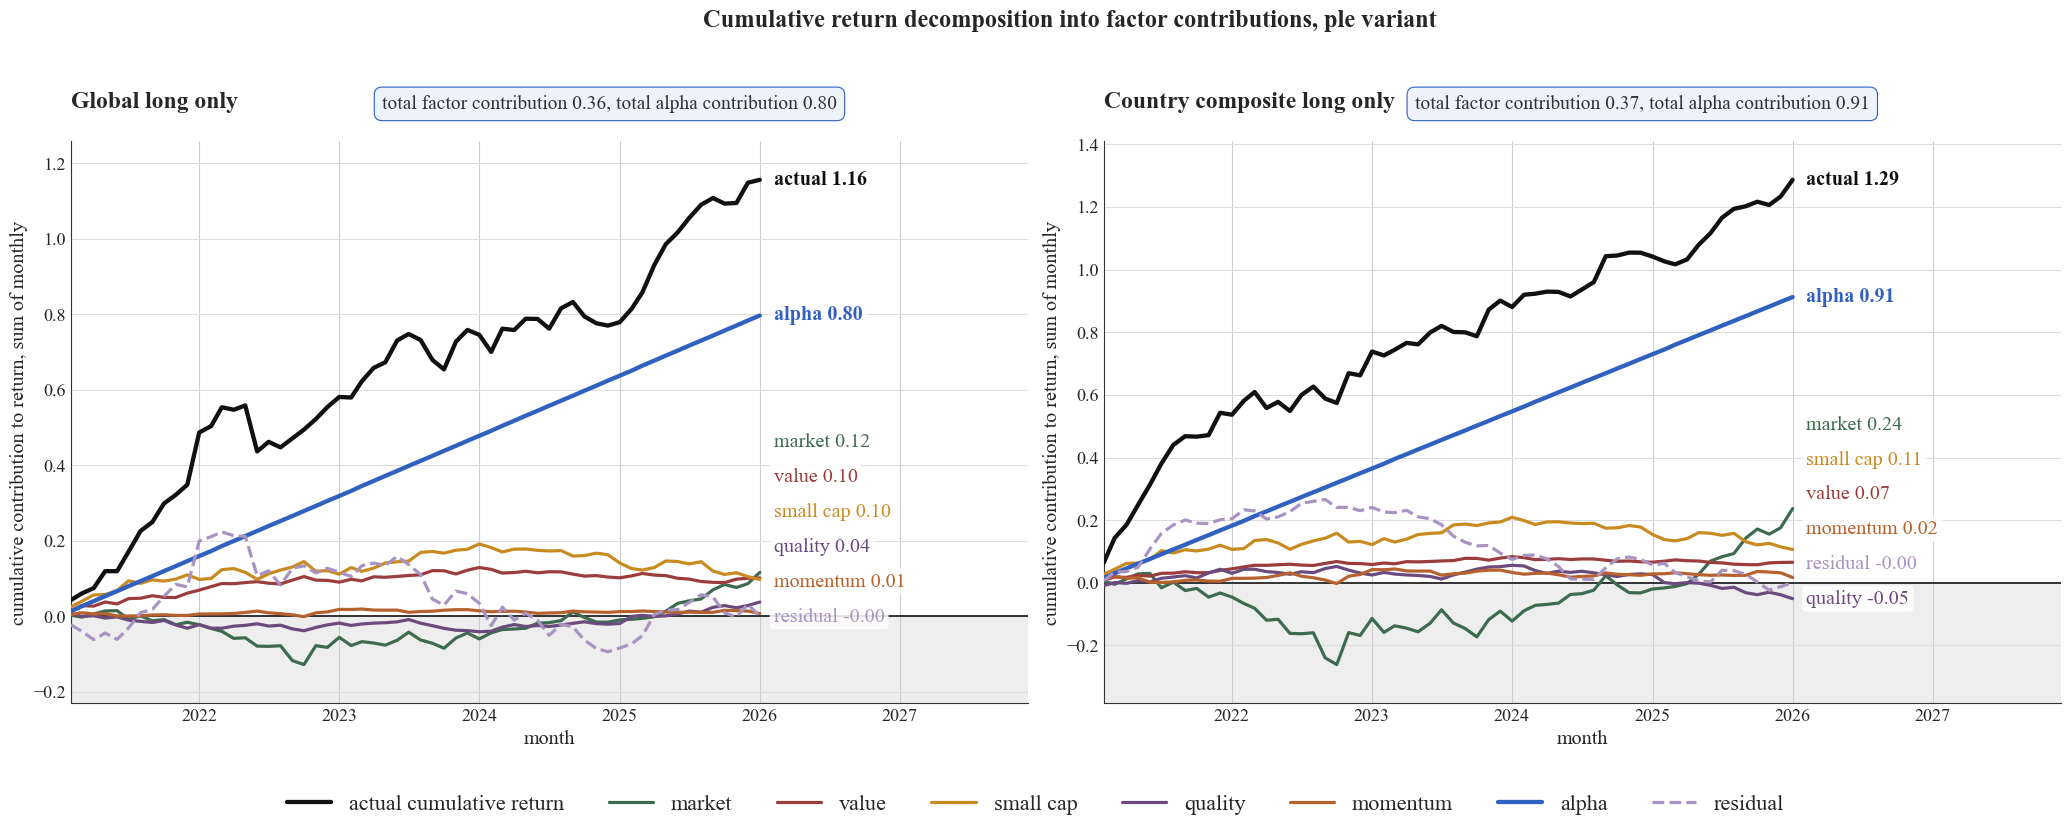

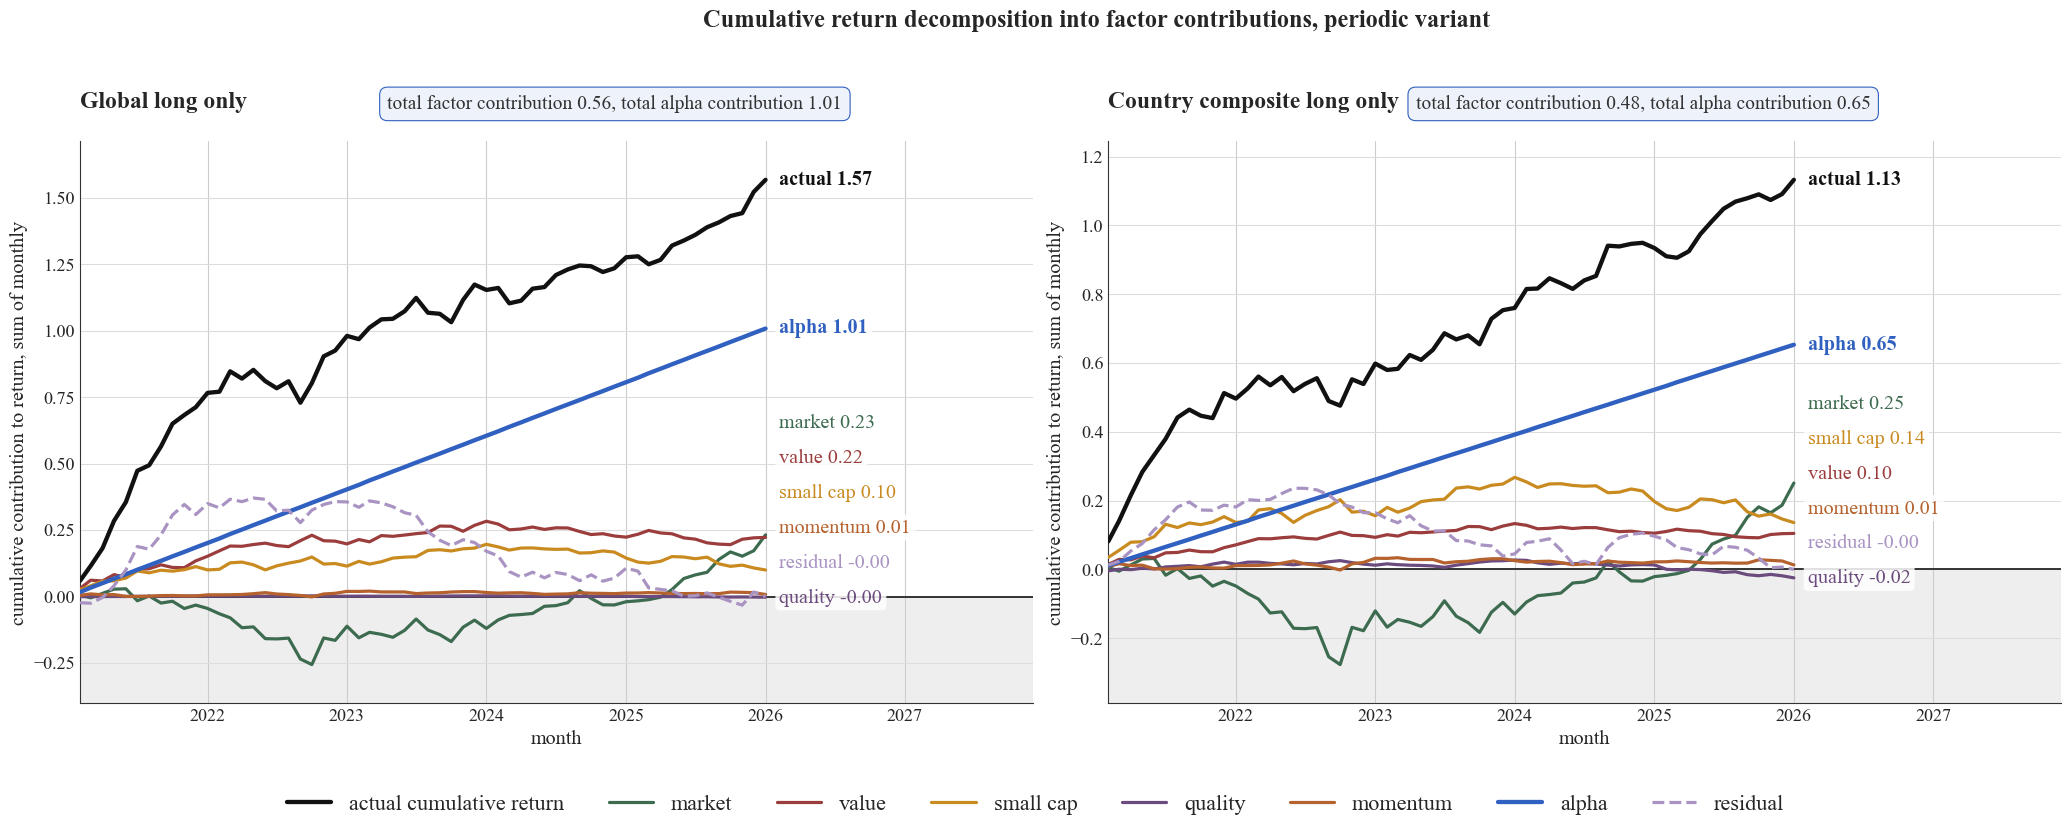

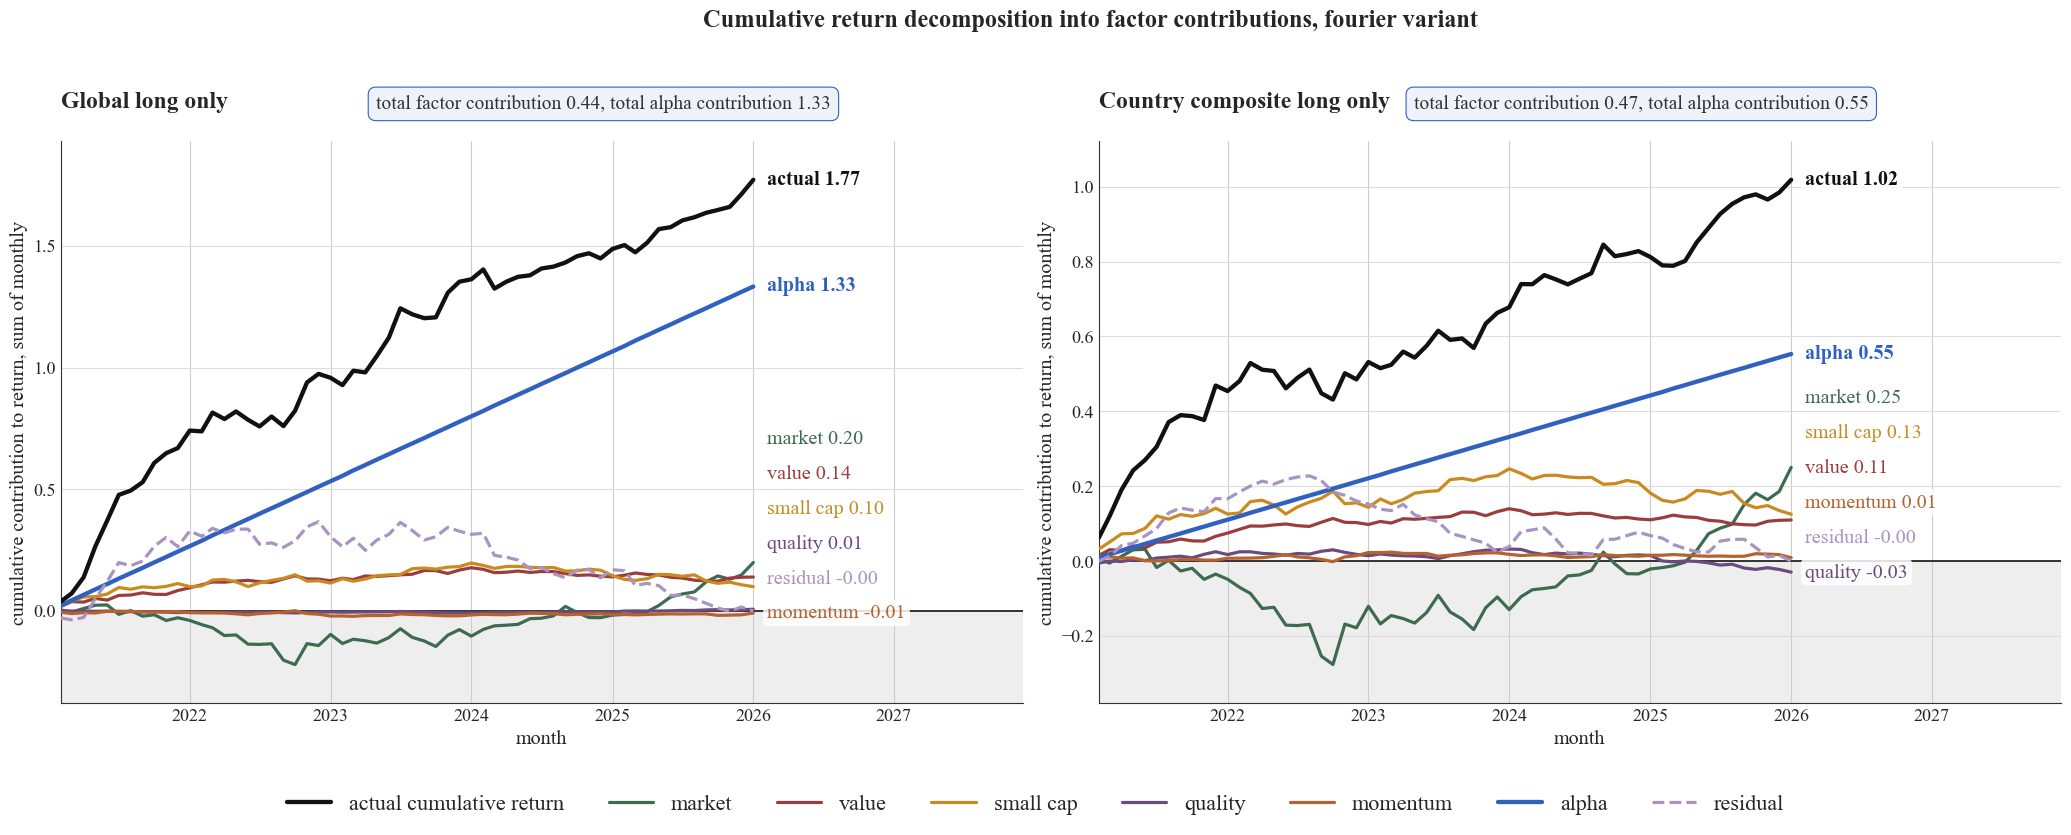

In [62]:
plot_labels = ["market", "value", "small cap", "quality", "momentum"]
line_colors = {
    "market": "#3d6b4f", "value": "#9c3d3d",
    "small cap": "#c98a1f", "quality": "#6b4a7d",
    "momentum": "#b5622e", "alpha": "#3060c0",
    "residual": "#a993c2"
}
strategy_titles = {
    "long_only": "Global long only",
    "country_composite_long_only": "Country composite long only"
}

for variant in variants:
    runs = [r for r in cached_runs if r["variant"] == variant]
    if not runs:
        continue

    fig, axes = plt.subplots(1, len(runs), figsize = (10.4 * len(runs), 8.7), squeeze = False)
    axes = axes[0]

    for ax, run in zip(axes, runs):
        merged = run["merged"]
        results = run["results"]

        # each factor contributes its loading multiplied by that factor realised
        # return, the intercept contributes a constant every month, and the residual
        # is carried explicitly so the components sum to the realised return exactly
        contributions = pd.DataFrame(index = merged.index)
        for col, label in zip(factor_cols, plot_labels):
            contributions[label] = results.params[col] * merged[col]
        contributions["alpha"] = results.params["const"]
        contributions["residual"] = results.resid

        cumulative = contributions.cumsum()
        timestamps = cumulative.index.to_timestamp()

        actual = merged["portfolio_return"].cumsum()
        ax.plot(timestamps, actual.values, color = "#111111", linewidth = 3.1,
                label = "actual cumulative return", zorder = 5)

        # each component is drawn from zero rather than stacked, so its sign and
        # magnitude can be read directly against the zero line
        series_labels = plot_labels + ["alpha", "residual"]
        for label in series_labels:
            values = cumulative[label].values
            style = "dashed" if label == "residual" else "solid"
            width = 3.1 if label == "alpha" else 2.3
            ax.plot(timestamps, values, color = line_colors[label], linewidth = width,
                    linestyle = style, label = label, zorder = 4)

        # plain light grey marks the negative half plane only
        ax.axhspan(-1e6, 0, color = "#c9c9c9", alpha = 0.30, zorder = 0)
        ax.axhline(0, color = "#333333", linewidth = 1.4, zorder = 1)

        span = cumulative[series_labels].values
        low = min(span.min(), actual.min(), 0)
        high = max(span.max(), actual.max())
        pad = (high - low) * 0.08
        ax.set_ylim(low - pad, high + pad)
        ax.set_xlim(timestamps[0], timestamps[-1] + pd.Timedelta(days = 700))

        # label each series at its final value, nudged apart vertically where several
        # series end close together, so no label is hidden behind another
        final_points = [(label, cumulative[label].iloc[-1]) for label in series_labels]
        final_points.append(("actual", actual.iloc[-1]))
        final_points.sort(key = lambda pair: pair[1])
        min_gap = (high - low + 2 * pad) * 0.062
        placed = []
        for label, value in final_points:
            position = value
            if placed and position - placed[-1][1] < min_gap:
                position = placed[-1][1] + min_gap
            placed.append((label, position, value))
        for label, position, value in placed:
            colour = "#111111" if label == "actual" else line_colors[label]
            weight = "bold" if label in ("actual", "alpha") else "normal"
            ax.annotate(f"{label} {value:.2f}", xy = (timestamps[-1], position),
                        xytext = (10, 0), textcoords = "offset points",
                        fontsize = 14.5, color = colour, va = "center", fontweight = weight,
                        bbox = dict(boxstyle = "round,pad=0.2", facecolor = "white",
                                    edgecolor = "none", alpha = 0.85))

        # title and totals box sit on the same row above the axes, placed by
        # explicit axes fraction coordinates, title left aligned, box right aligned
        ax.text(0.0, 1.05, strategy_titles.get(run["strategy"], run["strategy"]),
                transform = ax.transAxes, ha = "left", va = "bottom",
                fontsize = 17, fontweight = "bold")
        ax.tick_params(labelsize = 13)
        ax.set_ylabel("cumulative contribution to return, sum of monthly", fontsize = 14.5)
        ax.set_xlabel("month", fontsize = 14.5)
        ax.grid(axis = "y", color = "#dddddd", linewidth = 0.8, zorder = 0)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        total_factor = contributions[plot_labels].sum().sum()
        total_alpha = contributions["alpha"].sum()
        ax.text(0.8, 1.05,
                f"total factor contribution {total_factor:.2f}, total alpha contribution {total_alpha:.2f}",
                transform = ax.transAxes, ha = "right", va = "bottom", fontsize = 14, color = "#333333",
                bbox = dict(boxstyle = "round,pad=0.4", facecolor = "#eef2fa", edgecolor = "#3060c0"))

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc = "lower center", ncol = len(handles), frameon = False, fontsize = 16)
    fig.suptitle(f"Cumulative return decomposition into factor contributions, {variant} variant",
             fontsize = 17.5, fontweight = "bold",
             x= 0.34, y = 0.95, ha = "left")
    fig.tight_layout(rect = [0, 0.085, 1, 0.92])
    fig.savefig(plots_dir / f"factor_contribution_{variant}.png", dpi = 150)
    plt.show()

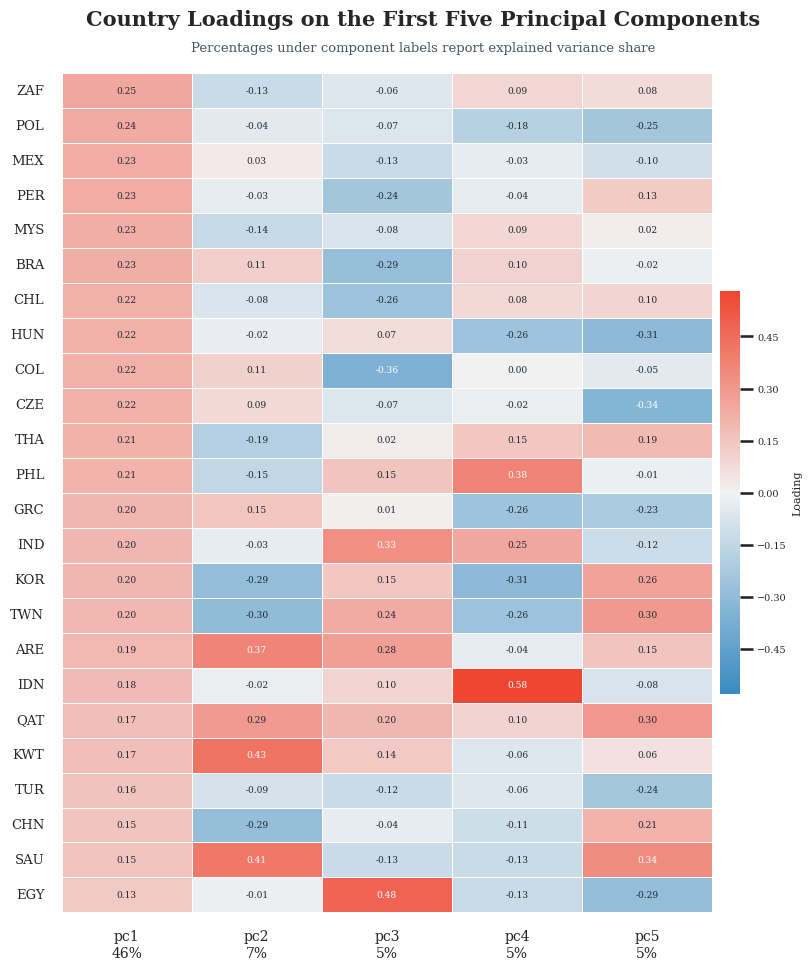

In [12]:
sns.set_theme(context="talk", style="white", font="serif")

order = loadings["pc1"].sort_values(ascending=False).index
loadings_sorted = loadings.loc[order]
limit = np.abs(loadings_sorted.values).max()
xtick_labels = [f"{c}\n{explained_variance_ratio[i]:.0%}" for i, c in enumerate(pca_cols)]
cmap = sns.diverging_palette(240, 15, s=85, l=55, center="light", as_cmap=True)

fig, ax = plt.subplots(figsize=(8.8, 10.4))

hm = sns.heatmap(loadings_sorted, ax=ax, cmap=cmap, vmin=-limit, vmax=limit, center=0, linewidths=0.45, linecolor="white", cbar_kws={"label": "Loading", "shrink": 0.48, "pad": 0.01})

for i in range(loadings_sorted.shape[0]):
    for j in range(loadings_sorted.shape[1]):
        value = loadings_sorted.iloc[i, j]
        ax.text(j + 0.5, i + 0.5, f"{value:.2f}", ha="center", va="center", fontsize=6.5, color="white" if abs(value) > limit * 0.55 else "#1f2933")

cbar = hm.collections[0].colorbar
cbar.ax.yaxis.set_major_locator(MaxNLocator(nbins=9))
cbar.ax.tick_params(labelsize=7)
cbar.ax.yaxis.label.set_size(8)

ax.set_xticklabels(xtick_labels, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9.5, rotation=0)
ax.set_xlabel("")
ax.set_ylabel("")

fig.suptitle("Country Loadings on the First Five Principal Components", fontsize=15, fontweight="bold", y=0.94)
fig.text(0.5, 0.9, "Percentages under component labels report explained variance share", ha="center", fontsize=9.5, color="#4A5568")

fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(plots_dir / "pca_country_loadings_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

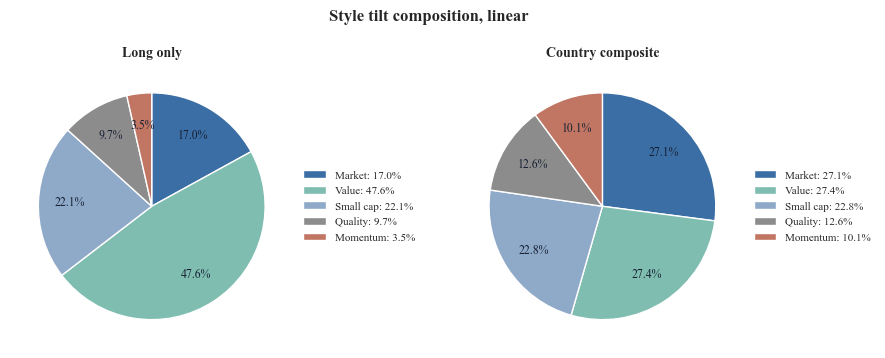

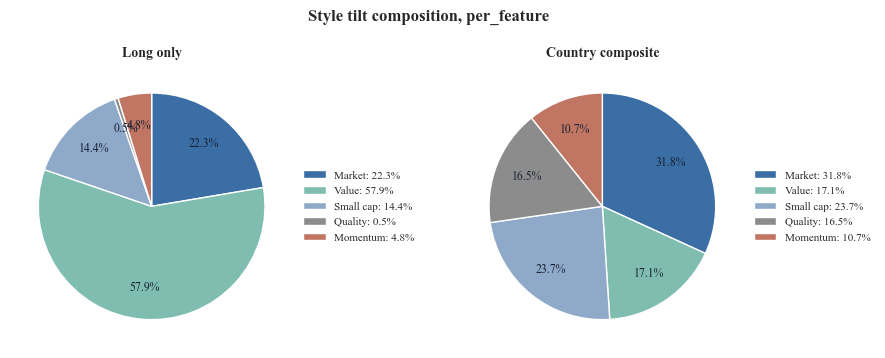

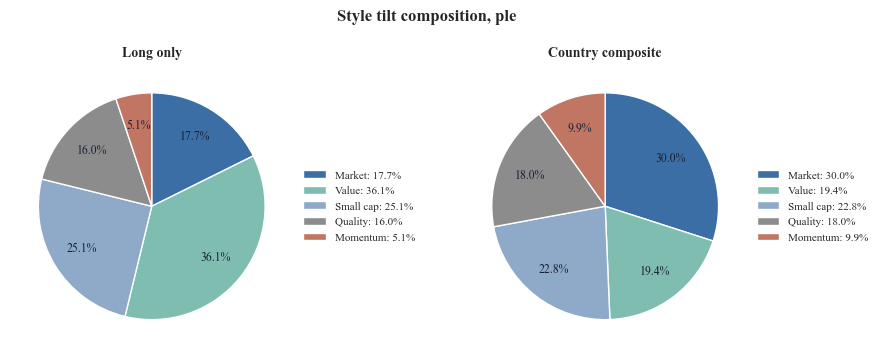

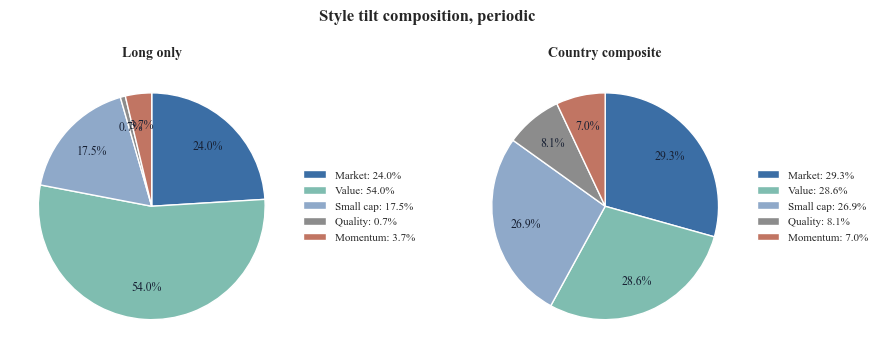

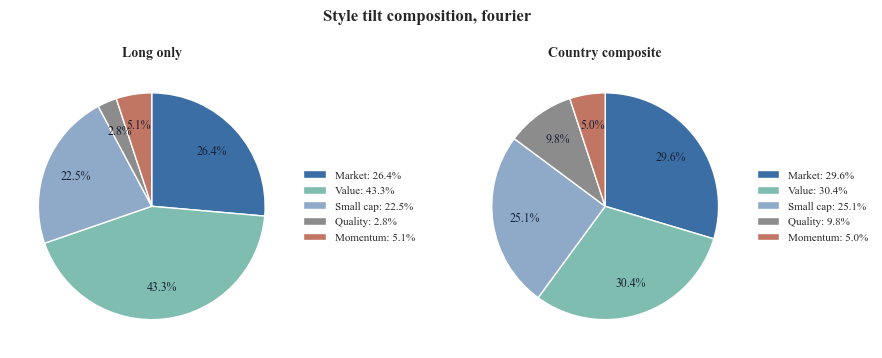

In [69]:
sns.set_theme(context="paper", style="white", font="serif")
plt.rcParams["font.serif"] = ["TeX Gyre Termes", "Liberation Serif", "Times New Roman", "DejaVu Serif"]

pie_labels = ["Market", "Value", "Small cap", "Quality", "Momentum"]
# same five colours used for the same five factors in the cumulative contribution
# chart, so a colour means the same thing everywhere in the dissertation rather
# than being re-picked per figure
pie_colors = ["#3b6ea5", "#7fbdb0", "#8fa9c9", "#8c8c8c", "#c17563"]
strategy_titles = {"long_only": "Long only", "country_composite_long_only": "Country composite"}

for variant in variants:
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))

    for ax, strategy in zip(axes, strategy_titles):
        run = next(r for r in cached_runs if r["variant"] == variant and r["strategy"] == strategy)
        shares = np.abs(run["results"].params[factor_cols].values)
        shares = shares / shares.sum()
        legend_labels = [f"{label}: {share:.1%}" for label, share in zip(pie_labels, shares)]

        wedges, _, _ = ax.pie(shares, colors=pie_colors, startangle=90, counterclock=False, autopct="%1.1f%%", pctdistance=0.72, wedgeprops={"edgecolor": "white", "linewidth": 1.0}, textprops={"fontsize": 8.5, "color": "#172033"})
        ax.legend(wedges, legend_labels, loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=8)
        ax.set_title(strategy_titles[strategy], fontsize=10, fontweight="bold")
        ax.set_aspect("equal")

    fig.suptitle(f"Style tilt composition, {variant}", fontsize=12, fontweight="bold")
    fig.tight_layout()
    fig.savefig(plots_dir / f"style_pie_strategy_comparison_{variant}.png", dpi=300, bbox_inches="tight")
    plt.show()